In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [77]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [78]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# Create FE_H range arrays
feh_neg = np.linspace(data['FE_H'].min(), 0, 300)  # negative metallicity
feh_pos = np.linspace(0, data['FE_H'].max(), 300)  # positive metallicity

# Compute boundary line
mgfe_neg = 0.12 - 0.13 * feh_neg        # sloped part
mgfe_pos = np.full_like(feh_pos, 0.12)  # flat part at +0.12
feh_line = np.concatenate([feh_neg, feh_pos])
mgfe_line = np.concatenate([mgfe_neg, mgfe_pos])
mgh_line = mgfe_line + feh_line
femg_line = feh_line - mgh_line

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_21485/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_21485/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_21485/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

(-1.05, 0.55)

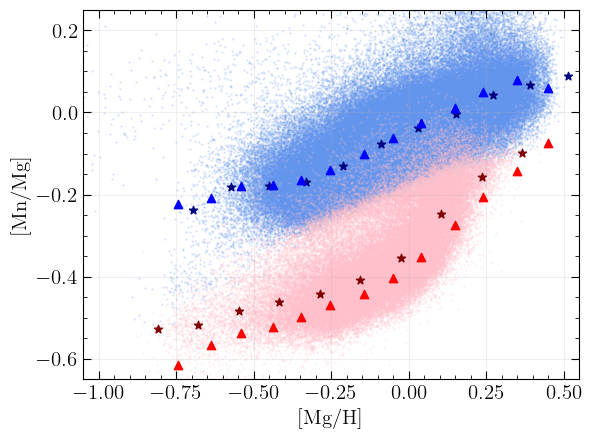

In [79]:
data_low_alpha = data_low_alpha[(data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
                                (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)]

data_high_alpha = data_high_alpha[(data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
                                (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)]

mnmg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)

mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]


plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

In [80]:
data_low_alpha_org = data_low_alpha
data_high_alpha_org = data_high_alpha

N = 10000

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
down_sample_flag = 0
if down_sample_flag == 1:
    data_low_alpha = downsample(data_low_alpha, N)
    data_high_alpha = downsample(data_high_alpha, N)

print(len(data_high_alpha_org))
print(len(data_low_alpha_org))

print(len(data_high_alpha))

68308
191737
68308


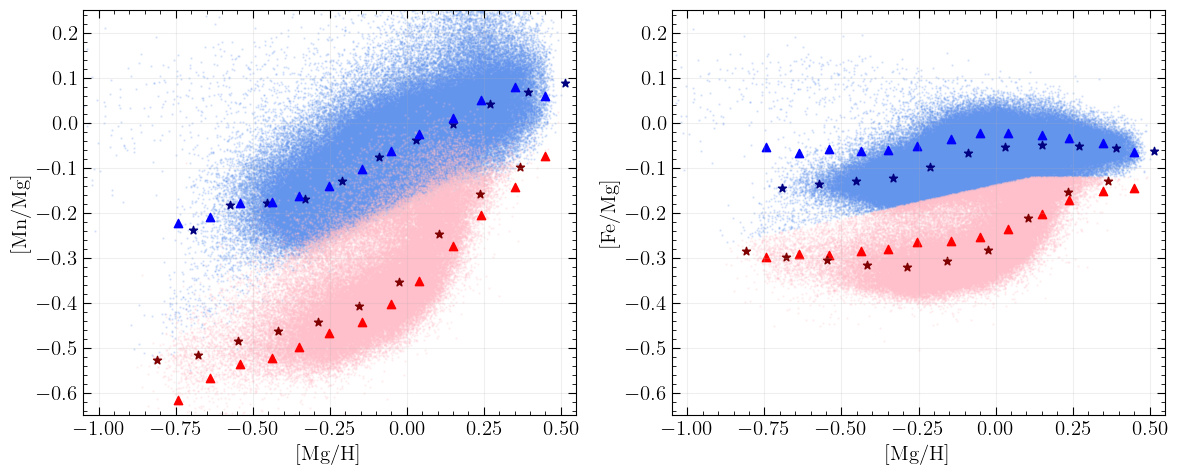

In [81]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# SFRS

In [82]:
def make_mock_pop(galaxy_model, sfr, n_samples=1000, error_on_met = 0.025):
    mstars = sfr/galaxy_model.tau_star_arr[0] * dt
    cdf_mstars = np.cumsum(mstars)/np.sum(mstars)
    u = np.random.rand(n_samples)
    sampled = np.searchsorted(cdf_mstars, u)
    gal_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H'])
    gal_df['O_H'] = np.random.normal(loc=galaxy_model.O_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_O'] = np.random.normal(loc=galaxy_model.Fe_O[sampled], scale = error_on_met, size=n_samples)
    gal_df['Mn_O'] = np.random.normal(loc=galaxy_model.Mn_O[sampled], scale = error_on_met, size=n_samples)
    gal_df['O_Fe'] = np.random.normal(loc=galaxy_model.O_Fe[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_H'] = np.random.normal(loc=galaxy_model.Fe_H[sampled], scale = error_on_met, size=n_samples)

    return gal_df

In [83]:
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)

dt =  0.014013913913913914


In [84]:
m_g_array_const = np.ones(len(t_array))
etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']

gals = []
gals_no_met_dep = []
gals_high_met_dep = []
gals_high_met_dep_Ia = []
gals_high_met_dep_cc = []
gals_no_met_dep_Ia = []
gals_no_met_dep_cc = []


for i in range(len(tau_stars)):
    gals.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))
    gals_no_met_dep.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=0, alpha_Ia_Mn=0))
    gals_high_met_dep.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=0.8, alpha_Ia_Mn=0.8))
    gals_high_met_dep_Ia.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_Ia_Mn=0.8))
    gals_high_met_dep_cc.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=0.8))
    gals_no_met_dep_Ia.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_Ia_Mn=0.0))
    gals_no_met_dep_cc.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=0.0))

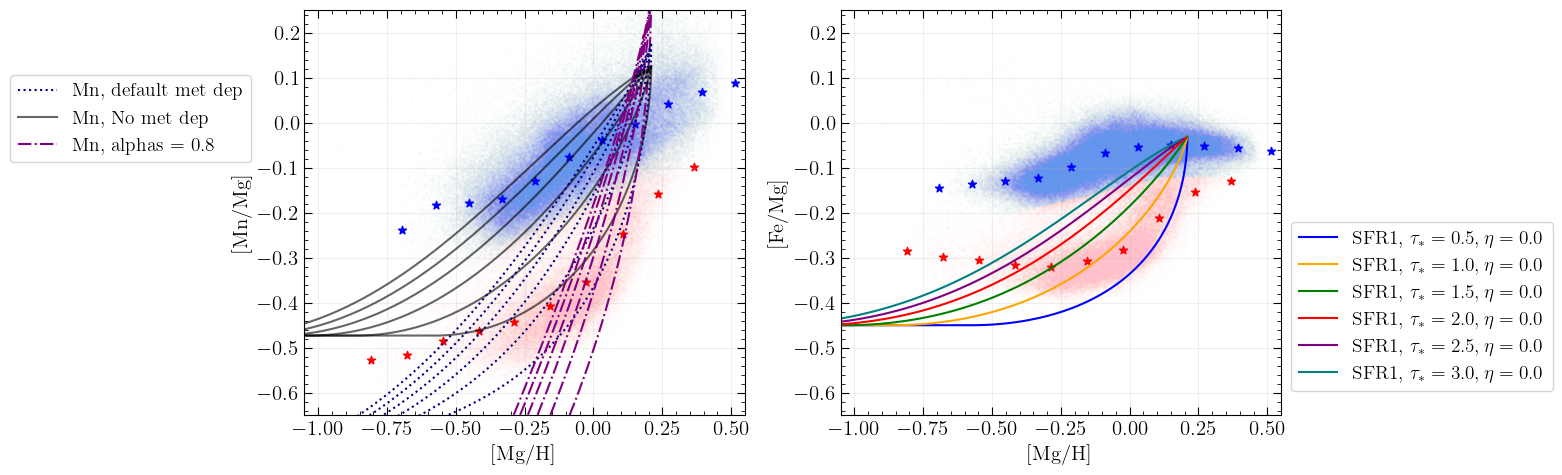

In [85]:
fig = plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    galnomet = gals_no_met_dep[i]
    galhighmet = gals_high_met_dep[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = 'navy', linestyle=':')
    #plt.plot(gal.O_H, gal.Fe_O, label = 'Fe', color = 'gray', alpha = 0.5, linestyle='--')
    plt.plot(galnomet.O_H, galnomet.Mn_O, label = 'Mn, No met dep', linestyle='-', color = 'black', alpha = 0.6)
    plt.plot(galhighmet.O_H, galhighmet.Mn_O, label = 'Mn, alphas = 0.8', linestyle='-.', color = 'purple')
    if i == 0:
        plt.legend(bbox_to_anchor=[-0.1,0.6])
#plt.plot(gal1.O_H, gal1.Mn_O, label = rf'SFR1, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'SFR1, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors[i])


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

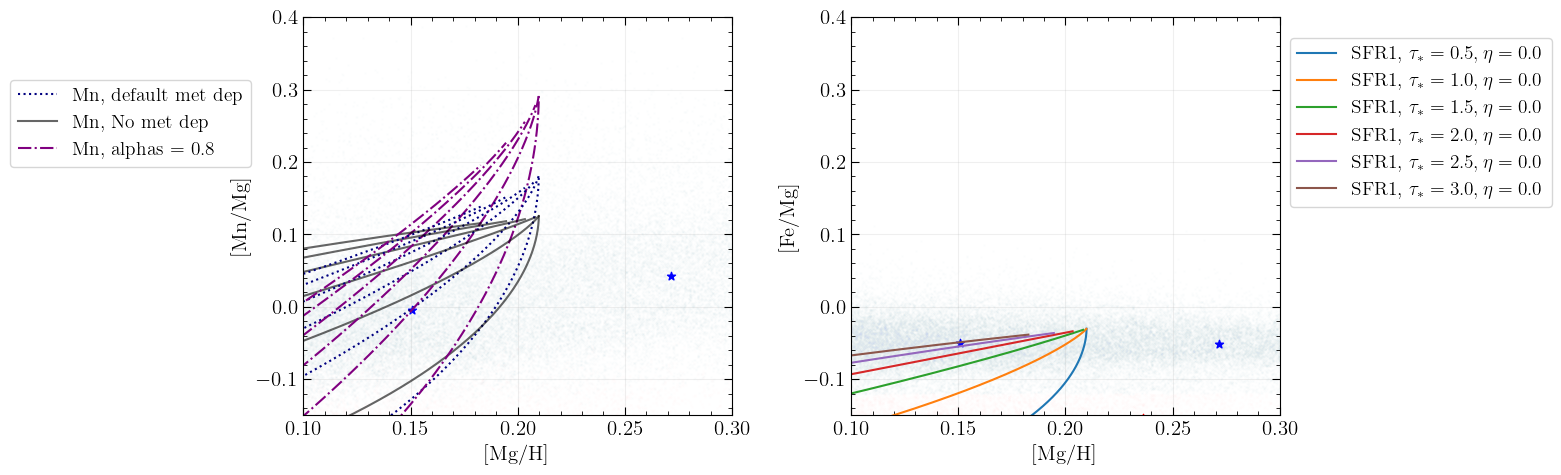

In [86]:
fig = plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    galnomet = gals_no_met_dep[i]
    galhighmet = gals_high_met_dep[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = 'navy', linestyle=':')
    #plt.plot(gal.O_H, gal.Fe_O, label = 'Fe', color = 'gray', alpha = 0.5, linestyle='--')
    plt.plot(galnomet.O_H, galnomet.Mn_O, label = 'Mn, No met dep', linestyle='-', color = 'black', alpha = 0.6)
    plt.plot(galhighmet.O_H, galhighmet.Mn_O, label = 'Mn, alphas = 0.8', linestyle='-.', color = 'purple')
    if i == 0:
        plt.legend(bbox_to_anchor=[-0.1,0.6])
#plt.plot(gal1.O_H, gal1.Mn_O, label = rf'SFR1, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.xlim(0.1,0.3)
plt.ylim(-0.15,0.4)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'SFR1, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $')


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(0.1,0.3)
plt.ylim(-0.15,0.4)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

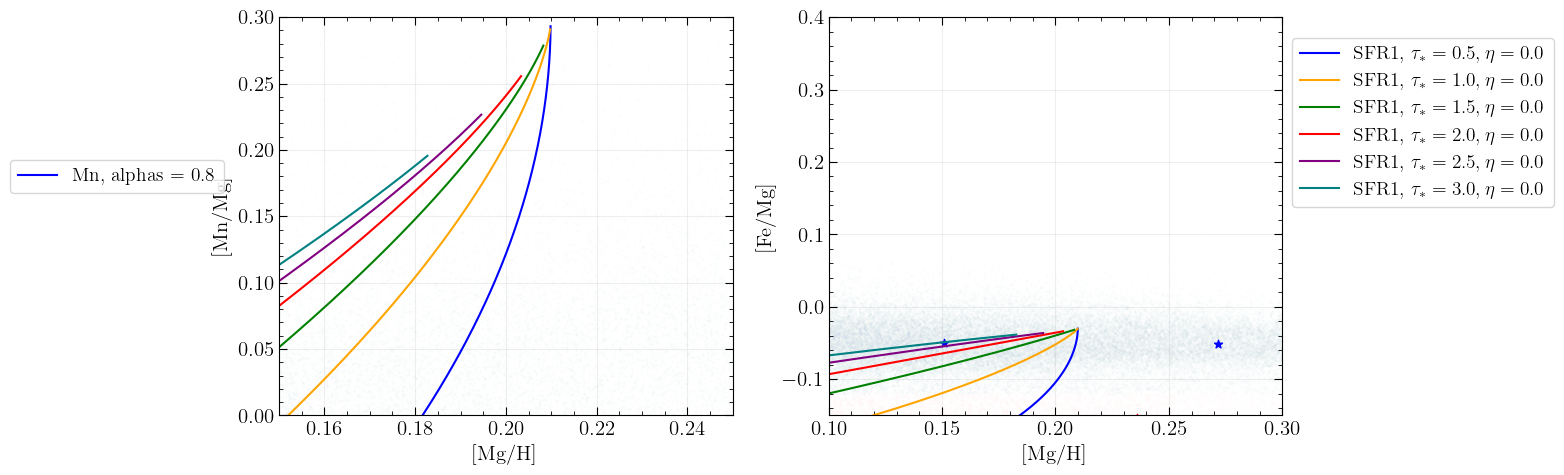

In [87]:
fig = plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    galnomet = gals_no_met_dep[i]
    galhighmet = gals_high_met_dep[i]
    #plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = 'navy', linestyle=':')
    #plt.plot(gal.O_H, gal.Fe_O, label = 'Fe', color = 'gray', alpha = 0.5, linestyle='--')
    #plt.plot(galnomet.O_H, galnomet.Mn_O, label = 'Mn, No met dep', linestyle='-', color = 'black', alpha = 0.6)
    plt.plot(galhighmet.O_H, galhighmet.Mn_O, label = 'Mn, alphas = 0.8', linestyle='-', color = colors[i])
    if i == 0:
        plt.legend(bbox_to_anchor=[-0.1,0.6])
#plt.plot(gal1.O_H, gal1.Mn_O, label = rf'SFR1, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.xlim(0.15,0.25)
plt.ylim(0,0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'SFR1, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors[i])


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(0.1,0.3)
plt.ylim(-0.15,0.4)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

0.2098345536740022
0.20974030563623827
0.20825076686879235
0.20333083495375198
0.1945688964937787
0.18269777324213327


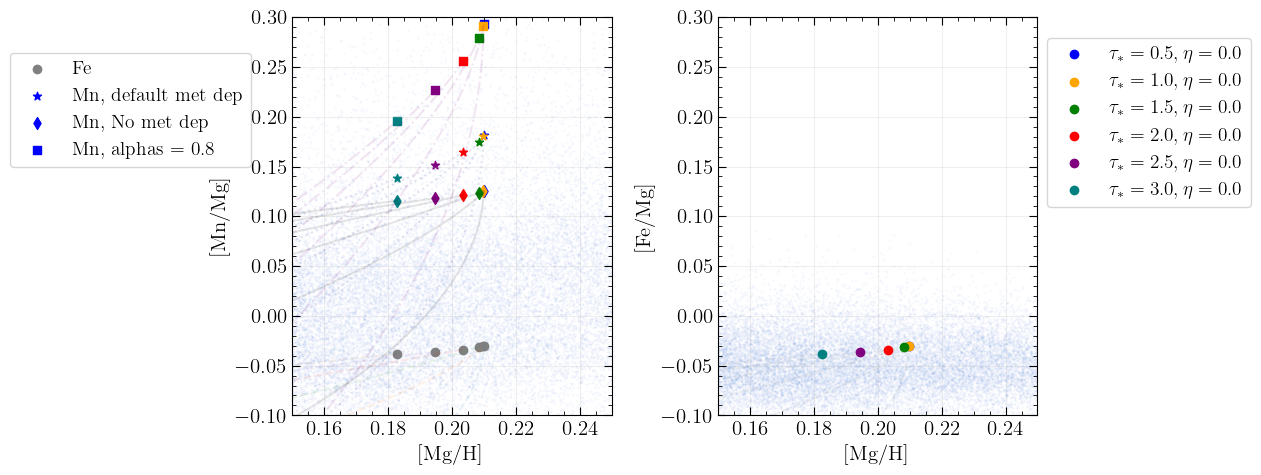

In [88]:
fig = plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.05, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.05, color = 'pink', s = 0.5)
#plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
#plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    galnomet = gals_no_met_dep[i]
    galhighmet = gals_high_met_dep[i]
    plt.scatter(gal.O_H[-1], gal.Fe_O[-1], label = 'Fe', color = 'gray')
    plt.scatter(gal.O_H[-1], gal.Mn_O[-1], label = 'Mn, default met dep', marker='*', color = colors[i])
    plt.scatter(galnomet.O_H[-1], galnomet.Mn_O[-1], label = 'Mn, No met dep', marker='d', color = colors[i])
    plt.scatter(galhighmet.O_H[-1], galhighmet.Mn_O[-1], label = 'Mn, alphas = 0.8', marker='s', color = colors[i])

    plt.plot(gal.O_H, gal.Mn_O, color = 'navy', linestyle=':', alpha = 0.1)
    plt.plot(gal.O_H, gal.Fe_O, linestyle='--', alpha = 0.1)
    plt.plot(galnomet.O_H, galnomet.Mn_O, linestyle='-', color = 'black', alpha = 0.1)
    plt.plot(galhighmet.O_H, galhighmet.Mn_O, linestyle='-.', color = 'purple', alpha = 0.1)
    print(galhighmet.O_H[-1])
    if i == 0:
        plt.legend(bbox_to_anchor=[-0.1,0.6])

#plt.plot(gal1.O_H, gal1.Mn_O, label = rf'SFR1, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(0.15,0.25)
plt.ylim(-0.1,0.3)
#plt.xlim(0.15,0.25)
#plt.ylim(0,0.3)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.05, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.05, color = 'pink', s = 0.5)
#plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
#plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    plt.scatter(gal.O_H[-1], gal.Fe_O[-1], label = rf'$\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors[i])
    plt.plot(gal.O_H, gal.Fe_O, color = 'gray', linestyle='--', alpha = 0.1)


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(0.15,0.25)
plt.ylim(-0.1,0.3)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

0.2098345536740022
0.20974030563623827
0.20825076686879235
0.20333083495375198
0.1945688964937787
0.18269777324213327


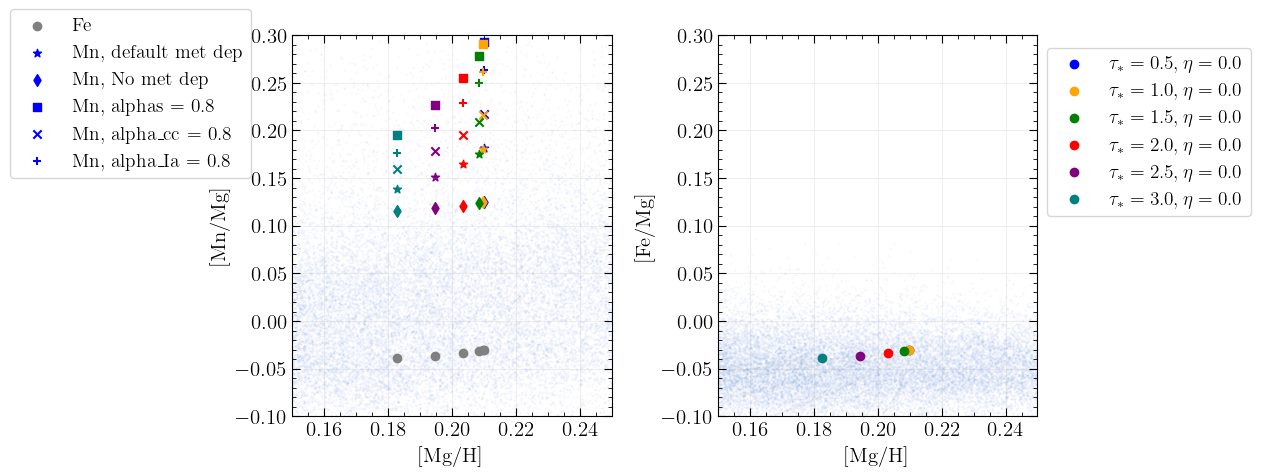

In [89]:
fig = plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.05, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.05, color = 'pink', s = 0.5)
#plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
#plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    galnomet = gals_no_met_dep[i]
    galhighmet = gals_high_met_dep[i]
    galhighmet_cc = gals_high_met_dep_cc[i]
    galhighmet_Ia = gals_high_met_dep_Ia[i]
    galnomet_cc = gals_no_met_dep_cc[i]
    galnomet_Ia = gals_no_met_dep_Ia[i]

    plt.scatter(gal.O_H[-1], gal.Fe_O[-1], label = 'Fe', color = 'gray')
    plt.scatter(gal.O_H[-1], gal.Mn_O[-1], label = 'Mn, default met dep', marker='*', color = colors[i])
    plt.scatter(galnomet.O_H[-1], galnomet.Mn_O[-1], label = 'Mn, No met dep', marker='d', color = colors[i])
    plt.scatter(galhighmet.O_H[-1], galhighmet.Mn_O[-1], label = 'Mn, alphas = 0.8', marker='s', color = colors[i])
    plt.scatter(galhighmet_cc.O_H[-1], galhighmet_cc.Mn_O[-1], label = 'Mn, alpha_cc = 0.8', marker='x', color = colors[i])
    plt.scatter(galhighmet_Ia.O_H[-1], galhighmet_Ia.Mn_O[-1], label = 'Mn, alpha_Ia = 0.8', marker='+', color = colors[i])
    #plt.scatter(galnomet_Ia.O_H[-1], galnomet_Ia.Mn_O[-1], label = 'Mn, alpha_Ia = 0', marker='^', color = colors[i])
    #plt.scatter(galnomet_cc.O_H[-1], galnomet_cc.Mn_O[-1], label = 'Mn, alpha_cc = 0', marker='v', color = colors[i])

    #plt.plot(gal.O_H, gal.Mn_O, color = 'navy', linestyle=':', alpha = 0.1)
    #plt.plot(gal.O_H, gal.Fe_O, linestyle='--', alpha = 0.1)
    #plt.plot(galnomet.O_H, galnomet.Mn_O, linestyle='-', color = 'black', alpha = 0.1)
    #plt.plot(galhighmet.O_H, galhighmet.Mn_O, linestyle='-.', color = 'purple', alpha = 0.1)
    print(galhighmet.O_H[-1])
    if i == 0:
        plt.legend(bbox_to_anchor=[-0.1,0.6])

#plt.plot(gal1.O_H, gal1.Mn_O, label = rf'SFR1, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(0.15,0.25)
plt.ylim(-0.1,0.3)
#plt.xlim(0.15,0.25)
#plt.ylim(0,0.3)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.05, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.05, color = 'pink', s = 0.5)
#plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
#plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    plt.scatter(gal.O_H[-1], gal.Fe_O[-1], label = rf'$\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors[i])
    plt.plot(gal.O_H, gal.Fe_O, color = 'gray', linestyle='--', alpha = 0.1)


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(0.15,0.25)
plt.ylim(-0.1,0.3)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

0.2098345536740022
0.20974030563623827
0.20825076686879235
0.20333083495375198
0.1945688964937787
0.18269777324213327


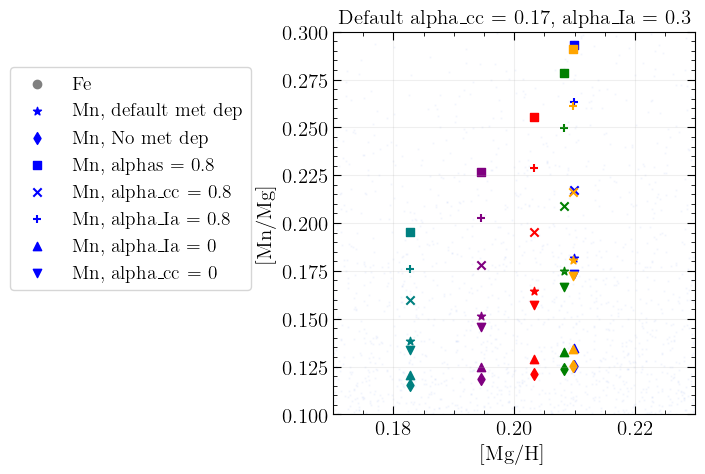

In [92]:
fig = plt.figure(figsize=(8,5))
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.05, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.05, color = 'pink', s = 0.5)
#plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
#plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals)):
    gal = gals[i]
    galnomet = gals_no_met_dep[i]
    galhighmet = gals_high_met_dep[i]
    galhighmet_cc = gals_high_met_dep_cc[i]
    galhighmet_Ia = gals_high_met_dep_Ia[i]
    galnomet_cc = gals_no_met_dep_cc[i]
    galnomet_Ia = gals_no_met_dep_Ia[i]

    plt.scatter(gal.O_H[-1], gal.Fe_O[-1], label = 'Fe', color = 'gray')
    plt.scatter(gal.O_H[-1], gal.Mn_O[-1], label = 'Mn, default met dep', marker='*', color = colors[i])
    plt.scatter(galnomet.O_H[-1], galnomet.Mn_O[-1], label = 'Mn, No met dep', marker='d', color = colors[i])
    plt.scatter(galhighmet.O_H[-1], galhighmet.Mn_O[-1], label = 'Mn, alphas = 0.8', marker='s', color = colors[i])
    plt.scatter(galhighmet_cc.O_H[-1], galhighmet_cc.Mn_O[-1], label = 'Mn, alpha_cc = 0.8', marker='x', color = colors[i])
    plt.scatter(galhighmet_Ia.O_H[-1], galhighmet_Ia.Mn_O[-1], label = 'Mn, alpha_Ia = 0.8', marker='+', color = colors[i])
    plt.scatter(galnomet_Ia.O_H[-1], galnomet_Ia.Mn_O[-1], label = 'Mn, alpha_Ia = 0', marker='^', color = colors[i])
    plt.scatter(galnomet_cc.O_H[-1], galnomet_cc.Mn_O[-1], label = 'Mn, alpha_cc = 0', marker='v', color = colors[i])

    #plt.plot(gal.O_H, gal.Mn_O, color = 'navy', linestyle=':', alpha = 0.1)
    #plt.plot(gal.O_H, gal.Fe_O, linestyle='--', alpha = 0.1)
    #plt.plot(galnomet.O_H, galnomet.Mn_O, linestyle='-', color = 'black', alpha = 0.1)
    #plt.plot(galhighmet.O_H, galhighmet.Mn_O, linestyle='-.', color = 'purple', alpha = 0.1)
    print(galhighmet.O_H[-1])
    if i == 0:
        plt.legend(bbox_to_anchor=[-0.2,0.3])

#plt.plot(gal1.O_H, gal1.Mn_O, label = rf'SFR1, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(0.17,0.23)
plt.ylim(0.1,0.3)
#plt.xlim(0.15,0.25)
#plt.ylim(0,0.3)

plt.title("Default alpha_cc = 0.17, alpha_Ia = 0.3")

plt.tight_layout()

Text(0, 0.5, 'Mg_H')

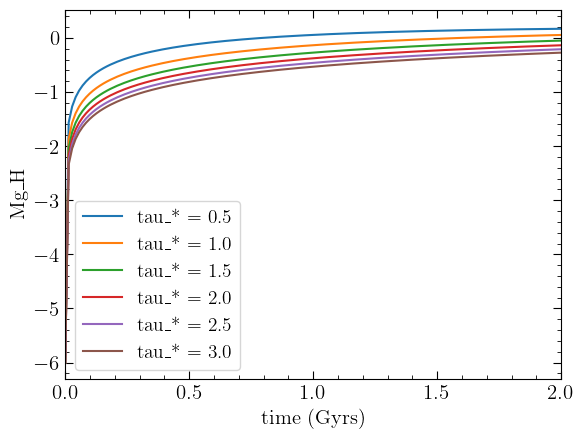

In [91]:
for i in range(len(gals)):
    gal = gals[i]
    plt.plot(gal.t, gal.Mg_H, label = f'tau_* = {gal.tau_star_arr[0]}')

plt.xlim(0,2)
plt.legend()
plt.xlabel('time (Gyrs)')
plt.ylabel('Mg_H')